<a href="https://colab.research.google.com/github/davidsjohnson/blockies-xai/blob/xai-david/invert_blockies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">
  <img src="https://raw.githubusercontent.com/lapalap/invert/main/assets/images/logo.svg" width="400"/>
</div>

<div align="center"><h1>Hello INVERT</h1>

Cloning the repository and installing the INVERT

In [1]:
! git clone https://github.com/lapalap/invert.git --quiet
! pip install git+file:///content/invert --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 57.5 MB/s eta 0:00:00


In [7]:
!rm -rf blockies-xai
!git clone --recurse-submodules https://github.com/davidsjohnson/blockies-xai
%cd blockies-xai
!git checkout xai-david
!git submodule update --init --recursive
%cd zennit-crp/
!git checkout metadata
%cd ../../

Cloning into 'blockies-xai'...
remote: Enumerating objects: 116, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 116 (delta 2), reused 8 (delta 2), pack-reused 108 (from 1)
Receiving objects: 100% (116/116), 174.69 MiB | 16.75 MiB/s, done.
Resolving deltas: 100% (41/41), done.
/content/blockies-xai
Updating files: 100% (9/9), done.
Branch 'xai-david' set up to track remote branch 'xai-david' from 'origin'.
Switched to a new branch 'xai-david'
Submodule 'zennit-crp' (https://github.com/davidsjohnson/zennit-crp.git) registered for path 'zennit-crp'
Cloning into '/content/blockies-xai/zennit-crp'...
Submodule path 'zennit-crp': checked out '2040c0d4526e465e952cfcc63ad1d43308f35084'
/content/blockies-xai/zennit-crp
Branch 'metadata' set up to track remote branch 'metadata' from 'origin'.
Switched to a new branch 'metadata'
/content


In [23]:
%cd ./blockies-xai/
!git checkout XAI
%cd ../

/content/blockies-xai
Branch 'XAI' set up to track remote branch 'XAI' from 'origin'.
Switched to a new branch 'XAI'
/content


Importing necessary packages

In [26]:
import warnings
warnings.filterwarnings("ignore")

from invert.explainer import Invert

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from PIL import Image

import pandas as pd
import json

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


# 1.  Loading the data

To make INVERT function properly, we need to get the activation values of neurons for a particular dataset, along with the corresponding concept labels. In this example, we fetch the activation tensor from the ResNet18 AvgPool layer (512 nerurons) using the ImageNet validation dataset, which consists of 50,000 images. Additionally, we retrieve sets of concept labels for each image.

In [3]:
import os
import tarfile
import requests
from pathlib import Path

def _download_url(url, file_path):
  response = requests.get(url, stream=True)
  response.raise_for_status()  # Raise an error for bad status codes
  with open(file_path, "wb") as file:
      for chunk in response.iter_content(chunk_size=8192):
          file.write(chunk)

def download_file(url, file_name, cache_dir="data", extract=True, force_download=False, archive_folder=None):
    # Ensure the cache directory exists
    os.makedirs(cache_dir, exist_ok=True)
    file_path = Path(cache_dir) / file_name

    # Download the file
    if not os.path.exists(file_path) or force_download:
        print(f"Downloading file from {url} to {file_path}...")
        _download_url(url, file_path)
        print(f"File downloaded to: {file_path}")
    else:
        print(f"File already exists at: {file_path}")

    if extract:
      with tarfile.open(file_path, "r:gz") as tar:
          tar.extractall(path=cache_dir)
      print(f"File extracted to: {cache_dir}")
      file_path = Path(cache_dir) / archive_folder if archive_folder is not None else Path(cache_dir)
    elif not extract and archive_folder is not None:
       file_path = Path(cache_dir) / archive_folder
       print(f"File already extracted to: {file_path}")

    return Path(file_path)

def load_dataframe(data_dir, dataset):
  data_dir = data_dir / dataset
  df = pd.read_json(data_dir / 'parameters.jsonl', lines=True)
  df['filename'] = df['id'] + '.png'
  df['ill'] = df['ill'].astype(int).astype(str)

  return df

In [4]:
CLASSES = ['Healthy', 'OC Degeneration']

load_checkpoints = True

modeltype = 'mobilenet'

ds = 'sick_ones_bendbias_v3_2class_normal'
eval_ds = 'sick_ones_bendbias_v3_2class_variation'

In [5]:
relative_model_path = "two4two_sickones_models_pytorch"
base_path = Path('./') / relative_model_path
base_path

PosixPath('two4two_sickones_models_pytorch')

In [6]:
data_dir = download_file(url="https://osf.io/download/kexzt/?view_only=adcc520b88cc4ea3b8236c5178ba3ab5",
                               file_name="blockies_datasets.tar.gz",
                               cache_dir='data', # change this if not using Colab
                               extract=True,
                               force_download=False,
                               archive_folder='blockies_datasets')
ds_dir = data_dir / ds
eval_ds_dir = data_dir / eval_ds
ds_dir, eval_ds_dir

<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()


File downloaded to: data/blockies_datasets.tar.gz
File extracted to: data


(PosixPath('data/blockies_datasets/sick_ones_bendbias_v3_2class_normal'),
 PosixPath('data/blockies_datasets/sick_ones_bendbias_v3_2class_variation'))

In [9]:
train_df = load_dataframe(ds_dir, 'train')
val_df = load_dataframe(ds_dir, 'validation')
test_df = load_dataframe(ds_dir, 'test')
eval_df = load_dataframe(eval_ds_dir, 'test')

In [11]:
mean = torch.tensor([0.8068, 0.7830, 0.8005])
std = torch.tensor([0.1093, 0.1136, 0.1029])

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mean, std=std)
])

In [12]:
class ImageDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(str(self.data_dir), str(row['filename'])) ## Added str
        image = Image.open(img_path).convert('RGB')
        label = int(row['ill'])
        b_id = row['id']

        if self.transform:
            image = self.transform(image)

        return image, label, b_id

In [13]:
train_dataset = ImageDataset(train_df, ds_dir / 'train', transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                              num_workers=0, pin_memory=True)

train_eval_dataset = ImageDataset(train_df, ds_dir / 'train', transform=transform)
train_eval_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False,
                                   num_workers=0, pin_memory=True)

val_dataset = ImageDataset(val_df,  ds_dir / 'validation', transform=transform)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False,
                            num_workers=0, pin_memory=True)

test_dataset = ImageDataset(test_df,  ds_dir / 'test', transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                             num_workers=0, pin_memory=True)

eval_dataset = ImageDataset(eval_df,  eval_ds_dir / 'test', transform=transform)
eval_dataloader = DataLoader(eval_dataset, batch_size=32, shuffle=False,
                             num_workers=0, pin_memory=True)

len(train_dataset), len(val_dataset), len(test_dataset), len(eval_dataset)

(40000, 1000, 3000, 3000)

In [14]:
def load_resnet18(num_classes, pretrained=True, checkpoint_path=None):
  model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
  model.fc = nn.Linear(model.fc.in_features, num_classes)

  if checkpoint_path:
      checkpoint = torch.load(checkpoint_path, map_location='cpu')
      model.load_state_dict(checkpoint)
      print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

In [21]:
checkpoint_path = Path('./blockies-xai/ResNet18/sick_ones_bendbias_v3_2class_normal/mobilenet/torch_resnet18/')

In [17]:
# Define loss function
criterion = nn.CrossEntropyLoss()
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [24]:
model = load_resnet18(num_classes=len(CLASSES),
                         pretrained=False,
                         checkpoint_path=checkpoint_path / 'final' / 'best_model.pth')
model.to(device)
model.eval()  # Set model to evaluation mode

Loaded checkpoint from: blockies-xai/ResNet18/sick_ones_bendbias_v3_2class_normal/mobilenet/torch_resnet18/final/best_model.pth


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [28]:
# in this demo we download activations -- set this varibale to True to collect activations by yourself
from tqdm import tqdm
import torchvision

extract_activations = True

# if set to True provide path to dataset, i.e. Imagenet validation
PATH = 'path to imagenet'

if extract_activations:

    # put hook on layer
    activation = {}
    def get_activation(name):
        def hook(model, input, output):
            activation[name] = output.data
        return hook

    model.avgpool.register_forward_hook(get_activation('avgpool'))

    A = torch.zeros([len(test_dataset),512]).cpu()

    counter = 0

    with torch.no_grad():
        for i, x in tqdm(enumerate(test_dataloader)):
            x = x[0]
            x = x.float().data.to(device)

            outputs = model(x).data
            # avgpool layer has shape [B, 512, 1, 1]
            A[counter:counter + x.shape[0],:] = activation['avgpool'][:, :, 0, 0].data.cpu()
            counter += x.shape[0]
else:
    # Downloading ResNet18 AvgPool layer activations across ImageNet validation dataset
    ! wget -O A50k_resnet18_avgpool.tnsr https://www.dropbox.com/scl/fi/9j6x953n7d504hgtn5eaa/A50k_avgpoolresnet18_val.tnsr?rlkey=tx9wz371p5m541799qzr18ybq&dl=0 --quiet
    A = torch.load("/content/A50k_resnet18_avgpool.tnsr")

print(A.shape)

94it [00:05, 17.12it/s]

torch.Size([3000, 512])


In [30]:
# Downloading labels of ImageNet validation dataset
# ! wget -O ILSVRC2012_val.csv https://www.dropbox.com/scl/fi/d7silvnhen7mujts1h6by/ILSVRC2012_val.csv?rlkey=svo4g8f4wegx4ijo3pwfe3p6p&dl=0 --quiet

Each image is associated with a one-hot-encoding vector that represents the concepts it relates to. More on this to come...

In [47]:
df = pd.read_csv('/content/data/test_concepts.csv') #extracted blockies concepts
one_hot_labels = torch.tensor(df[df.columns[:]].values).bool()
torch.save(one_hot_labels, 'one_hot_labels.tnsr')

In [48]:
df

,num_diff_1,num_diff_2,num_diff_3,bending_high,bending_low,main_bone_shape_low,main_bone_shape_high,main_bone_shape_mutation,secondary_bone_shape_low,secondary_bone_shape_high,...,color_blue,bg_color_red,bg_color_neutral,bg_color_blue,roll_low,roll_high,pitch_low,pitch_high,yaw_low,yaw_high
0,1,0,0,0,1,1,0,0,1,0,...,0,1,0,0,1,0,1,0,0,1
1,0,0,1,0,1,0,1,0,0,0,...,1,1,0,0,1,0,1,0,1,0
2,1,0,0,0,1,0,1,0,0,1,...,1,0,0,1,1,0,1,0,0,1
3,1,0,0,0,1,0,1,0,0,0,...,0,0,0,1,1,0,1,0,1,0
4,0,0,1,0,1,1,0,0,0,1,...,0,0,0,1,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,1,0,1,0,1,0,0,1,0,...,1,0,0,1,1,0,1,0,1,0
2996,1,0,0,0,1,1,0,0,1,0,...,0,0,1,0,1,0,1,0,0,1
2997,0,1,0,0,1,1,0,0,1,0,...,1,1,0,0,1,0,1,0,0,1
2998,0,1,0,0,1,1,0,0,1,0,...,1,0,0,1,1,0,1,0,1,0


The cloned repository contains a JSON file where we've gathered information and metadata about all 1,481 concepts used for the explanations.

In [49]:
data = open('/content/data/concepts_description.json')
data = data.read()
data = json.loads(data)

In [50]:
print(data['0'])

{'name': 'num_diff_1', 'definition': 'Number of secondary bones: 1', 'offset': 'num_diff_1'}


In [51]:
print(data['1'])

{'name': 'num_diff_2', 'definition': 'Number of secondary bones: 2', 'offset': 'num_diff_2'}


# 2. INVERT explanation

Following that, we proceed with the inversion explanation for neuron 296 in the AveragePooling layer of the ResNet18 model. Our first step involves initializing the Invert and loading the activations.

First, we initialize Invert class and load the data labebls in a form of one-hot-encoded data.

In [52]:
explainer = Invert(
        device = device,
    )

explainer.load_concept_labels(labels_path='one_hot_labels.tnsr',
                              description_path='/content/data/concepts_description.json'
                              )

Now we can run the INVERT procedure for the neuron 296. We set L = 3, B = 3, and $\alpha$ = 0.002.

In [70]:
A

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0204, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.1543, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0029, 0.0000]])

In [63]:
r = 476
L = 3
B = 3

explanation = explainer.explain_representation(A = A[:, r],
                                  L = L,
                                  B = B,
                                  min_fraction=0.002
                                  )

best_explanation = explanation[0]
best_explanation

{'formula': main_bone_shape_mutation & tucked_head & ~bending_high,
 'length': 3,
 'metric': tensor(0.8978, device='cuda:0'),
 'differentiability': tensor(0.7957, device='cuda:0'),
 'concept_fraction': tensor(0.0377, device='cuda:0')}

Resulting formula achieves AUROC of 0.9151 and has a support of 0.4% (200 images) of the dataset.

In the process of generating formulas, concepts are encoded using their corresponding WordNet offset. We can translate this into a more human-understandable form.

We can take a look at the "support" of the explanation -- set of datapoints, that correspond to the resulting explanation.

In [64]:
def find_by_offset(search_value:str, d:dict):
  for k in d:
    if d[k]['offset'] == search_value:
      return d[k]

print("Explanation for neuron {r}: ".format(r = r))
print(best_explanation['formula'])

human_readable_explanation = str(best_explanation['formula'])

print('\nHuman-understandable concepts: ')
for element in best_explanation['formula']._distinct_concepts:
  label = find_by_offset(str(element), data)
  print(element, label['name'], label['definition'])
  human_readable_explanation = human_readable_explanation.replace(str(element), label['name'])

print('\nHuman-readable explanation: {e}'.format(e = human_readable_explanation))

Explanation for neuron 476: 
main_bone_shape_mutation & tucked_head & ~bending_high

Human-understandable concepts: 
main_bone_shape_mutation main_bone_shape_mutation Main bone shape: mutation
tucked_head tucked_head Head position: tucked
bending_high bending_high Bending: high

Human-readable explanation: main_bone_shape_mutation & tucked_head & ~bending_high


We can take a look at a labels for the explanation

In [66]:
buffer = best_explanation['formula'](explainer.memdict).cpu()
print(buffer.shape)
print(buffer.sum())

torch.Size([3000])
tensor(113)


We can visualize the difference in the activation distribution of neuron 296 across data points corresponding to the explanation versus all other data points.

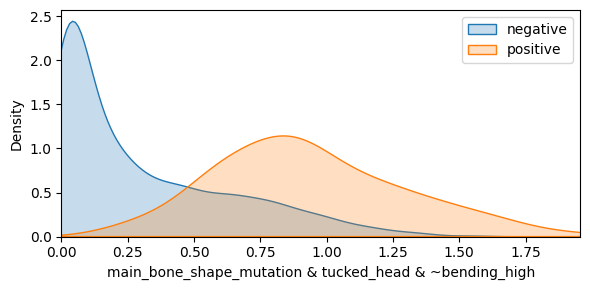

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

ig, ax = plt.subplots(figsize=(6, 3))
sns.kdeplot(data=A[buffer == False, r],
            color='tab:blue', label='negative', fill=True, ax=ax)
sns.kdeplot(data=A[buffer == True, r],
            color='tab:orange', label='positive', fill=True, ax=ax)

# ax.set_ylim((0, 1.))
ax.set_xlim((0, A[:, r].max()))
ax.legend()
ax.set_title('')
ax.set_xlabel(human_readable_explanation)
plt.tight_layout()
plt.show()

We can observe that indeed, activations of the data points corresponding to the resulting explanation (in orange) are generally significantly higher than for all other points (in blue).

Furthermore, we can conduct a statistical significance check to ensure that this difference is not merely a random occurrence.

In [69]:
explainer.get_p_value(A[:, r], best_explanation['formula'])

np.float64(8.108615163195991e-47)

We observe that the p-value is very small, which enables us to assert the statistical significance of the result.

# 3. Checking on local explanations

To further illustrate the behavior of the studied neuron, we can closely examine its local explanations. For this purpose, we gathered several images of boxes and visualized Grad-Cam explanations for neuron 296.

In [ ]:
!pip install grad-cam --quiet

from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 46.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


We download several images of boxes from wikimedia.

In [ ]:
! wget -O box1.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/5/56/Large_Wooden_box.jpg/800px-Large_Wooden_box.jpg --quiet
! wget -O box2.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/a/a8/Cardboard_box_with_cyan_background.png/640px-Cardboard_box_with_cyan_background.png --quiet
! wget -O box3.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/e/ee/Elaborate_wood_box_Tom_Tanaka.JPG/640px-Elaborate_wood_box_Tom_Tanaka.JPG --quiet
! wget -O box4.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/d/d9/L%C3%A5da_-_Livrustkammaren_-_107142.tif/lossy-page1-640px-L%C3%A5da_-_Livrustkammaren_-_107142.tif.jpg --quiet
! wget -O box5.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/8/8a/Box%2C_jewellery_%2851369557639%29.jpg/640px-Box%2C_jewellery_%2851369557639%29.jpg --quiet
! wget -O box6.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/3/31/Box_%2851361082165%29.jpg/640px-Box_%2851361082165%29.jpg --quiet

Define some transformations before passing images to the network.

In [ ]:
from torchvision import transforms
from PIL import Image
import torchvision.transforms.functional as F

class SquarePad:
    def __call__(self, image):
        max_wh = max(image.size)
        p_left, p_top = [(max_wh - s) // 2 for s in image.size]
        p_right, p_bottom = [max_wh - (s+pad) for s, pad in zip(image.size, [p_left, p_top])]
        padding = (p_left, p_top, p_right, p_bottom)
        return F.pad(image, padding, 0, 'constant')

transform = transforms.Compose([
 SquarePad(),
 transforms.Resize(224),
 transforms.ToTensor()
])

transform_normalize = transforms.Normalize(
     mean=[0.485, 0.456, 0.406],
     std=[0.229, 0.224, 0.225]
 )

Collect Grad-Cam explanations for the neuron 296.

In [ ]:
from torchvision import models
from tqdm import tqdm
import glob

model_stripped = models.resnet18(pretrained=True)
model_stripped.fc = torch.nn.Identity()

target_layers = [model_stripped.layer3[-1]]

# Construct the CAM object once, and then re-use it on many images:
cam = GradCAM(model=model_stripped, target_layers=target_layers)

targets = [ClassifierOutputTarget(r)]

images = []
local_explanations = []
for image_path in tqdm(glob.glob('box*')):
  img = Image.open(image_path)
  transformed_img = transform(img)
  input = transform_normalize(transformed_img).unsqueeze(0)

  images.append(transformed_img)
  grayscale_cam = cam(input_tensor=input, targets=targets)
  grayscale_cam = grayscale_cam[0, :]
  visualization = show_cam_on_image(transformed_img.transpose(0,1).transpose(1,2).numpy(), grayscale_cam, use_rgb=True)
  local_explanations.append(visualization)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 225MB/s]
  0%|          | 0/6 [00:00<?, ?it/s]


UnidentifiedImageError: cannot identify image file 'box2.jpg'

We can visualize downloaded images alongside Grad-Cam explanations.

In [ ]:
fig, axs = plt.subplots(2, len(images), figsize=(16,5))

fig.suptitle('Several images and corresponding local explanations for the Neuron {r}, ResNet18, AvgPool layer'.format(r=r))

for i in range(len(images)):
  axs[0][i].imshow(images[i].transpose(0,1).transpose(1,2))
  axs[0][i].set_axis_off()
  axs[1][i].imshow(local_explanations[i])
  axs[1][i].set_axis_off()


From this, we can observe that indeed this neuron detects square-shaped box-like objects, as suggested by the INVERT method.

In summary, INVERT offers a straightforward approach to link neurons with human-understandable concepts they detect. The metric of alignment between explanation and the neuron (AUROC) is easily interpretable and enables statistical significance testing. By labeling neurons within the models, we can explain interesting circuits within the models, further enhancing our understanding of their decision-making processes.